# Sentiment140 training data EDA

File has **no header**; columns assigned per official format.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

_HERE = Path.cwd().resolve()
if (_HERE / "data" / "datasets").is_dir():
    PROJECT_ROOT = _HERE
elif (_HERE.parent / "data" / "datasets").is_dir():
    PROJECT_ROOT = _HERE.parent
else:
    raise FileNotFoundError("Run from repo root or notebooks/")

sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import eda_helpers as edh

pd.set_option("display.max_colwidth", 100)

try:
    from IPython.display import display
except ImportError:
    display = print

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis


## Load with explicit schema

In [2]:
path = edh.datasets_root(PROJECT_ROOT) / "sentiment140" / "training.1600000.processed.noemoticon.csv"
df = edh.load_sentiment140(path)
print("shape:", df.shape)
print("columns:", list(df.columns))
display(df.head())


shape: (1600000, 6)
columns: ['polarity', 'tweet_id', 'date', 'query', 'user', 'text']


,polarity,tweet_id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Thi..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School to...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you a..."


## Nulls and duplicates

In [3]:
print(df.isna().sum())
print("duplicate rows:", int(df.duplicated().sum()))
print("duplicate texts:", int(df["text"].duplicated().sum()))


polarity    0
tweet_id    0
date        0
query       0
user        0
text        0
dtype: int64
duplicate rows: 0
duplicate texts: 18534


## Label distribution

Sentiment140 polarity: **0 = negative**, **2 = neutral**, **4 = positive**. Remap to 3-class `0,1,2` as: 0→0, 2→1, 4→2.

polarity
0    800000
4    800000
Name: count, dtype: int64


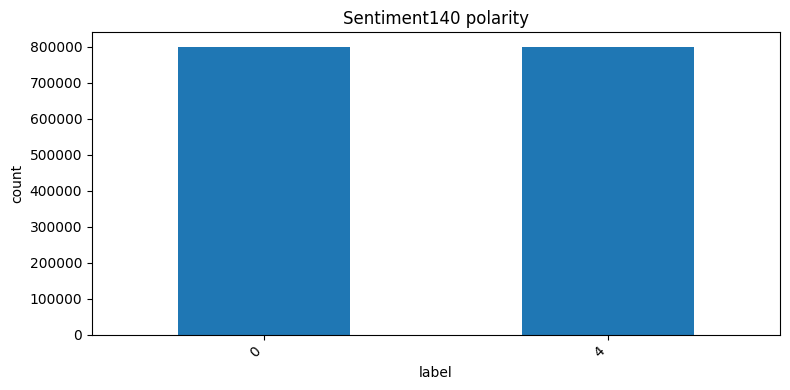

In [4]:
vc = df["polarity"].value_counts().sort_index()
print(vc)
edh.plot_label_counts(vc, "Sentiment140 polarity")


## Text length

chars mean/median: 74.09011125 69.0
words mean/median: 13.176150625 12.0


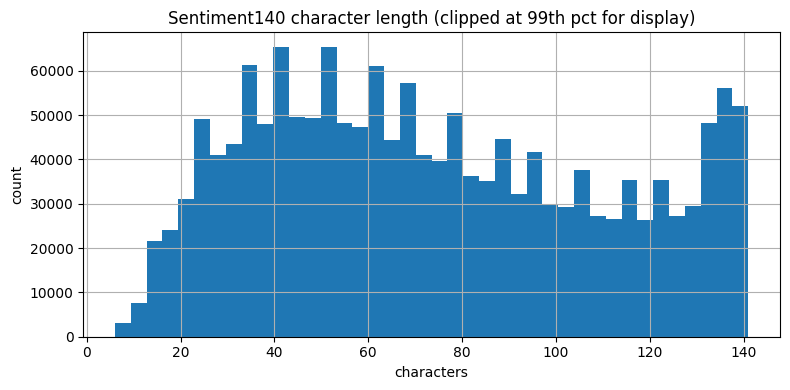

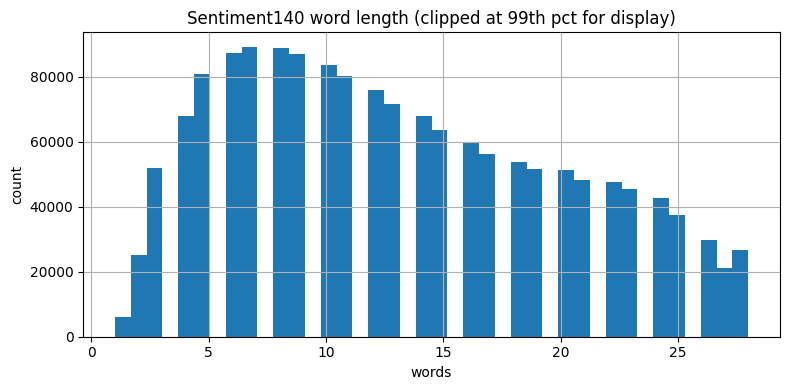

In [5]:
char_len, word_len = edh.char_word_lengths(df["text"])
print("chars mean/median:", float(char_len.mean()), float(char_len.median()))
print("words mean/median:", float(word_len.mean()), float(word_len.median()))
edh.plot_hist_length(char_len, "Sentiment140 character length", "characters")
edh.plot_hist_length(word_len, "Sentiment140 word length", "words")


## URLs, mentions, hashtags

In [6]:
print(edh.text_pattern_stats(df["text"]))


{'url_pct': np.float64(4.7365625), 'mention_pct': np.float64(46.155812499999996), 'hashtag_pct': np.float64(2.2404375), 'emoji_pct': np.float64(0.0)}


## Sample texts

In [7]:
for p in [0, 2, 4]:
    sub = df.loc[df["polarity"] == p]
    if len(sub) == 0:
        continue
    print("\n--- polarity", p, "---")
    for _, row in sub.head(2).iterrows():
        print(repr(str(row["text"])[:200]))



--- polarity 0 ---
"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"
"is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!"

--- polarity 4 ---
'I LOVE @Health4UandPets u guys r the best!! '
'im meeting up with one of my besties tonight! Cant wait!!  - GIRL TALK!!'


## Quality & preprocessing

- Remap polarity to consecutive labels for softmax.
- Watch latin-1 mojibake; use consistent decoding in pipelines.
- Sample or shard for manageable training runs.

In [8]:
summary = {
    "dataset": "sentiment140",
    "row_count": int(len(df)),
    "text_column": "text",
    "label_column": "polarity",
    "label_space": "0 (neg), 2 (neu), 4 (pos)",
    "avg_word_count": float(word_len.mean()),
    "median_word_count": float(word_len.median()),
    "duplicate_text_pct": edh.duplicate_text_pct(df["text"]),
    "null_pct": edh.null_fraction_df(df) * 100.0,
    "preprocessing": "Map 0/2/4 -> 0/1/2; dedupe optional; filter empty.",
}
path = edh.save_eda_summary("sentiment140", summary, PROJECT_ROOT)
print("Saved:", path)


Saved: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis/data/processed/eda_summaries/sentiment140.json
